In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import math
from imblearn.over_sampling import SMOTE
from collections import Counter

from scipy.stats import shapiro, kstest, norm

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score, auc
from sklearn.pipeline import Pipeline

<h1>Reading text files</h1>

In [2]:
zip_path = 'set-a.zip'
outcomes_path = 'Outcomes-a.txt'
extract_dir = 'extracted_data'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

data_list = []

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.txt') and file != outcomes_path:
            file_path = os.path.join(root, file)
            try:
                record_id = int(file.replace('.txt', ''))
                patient_df = pd.read_csv(file_path)

                if patient_df.empty:
                    continue

                # Convert 0 or negative values for Height/Weight to NaN
                # Also common for features like HeartRate or SysBP to have 0s as errors
                invalid_mask = (
                    ((patient_df['Parameter'] == 'Height') & (patient_df['Value'] <= 0)) |
                    ((patient_df['Parameter'] == 'Weight') & (patient_df['Value'] <= 0)) |
                    (patient_df['Value'] < 0)
                )
                patient_df.loc[invalid_mask, 'Value'] = np.nan

                patient_data = patient_df.groupby('Parameter')['Value'].mean().to_dict()
                patient_data['RecordID'] = record_id
                data_list.append(patient_data)

            except ValueError:
                continue

if not data_list:
    raise ValueError("No patient data was found. Check if the zip file was extracted correctly.")

df_features = pd.DataFrame(data_list)

df_features.set_index('RecordID', inplace=True)

outcomes = pd.read_csv(outcomes_path)
outcomes.set_index('RecordID', inplace=True)

df = df_features.join(outcomes, how='inner')

In [3]:
df.head()

,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,...,SysABP,Albumin,TroponinI,TroponinT,Cholesterol,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
RecordID,,,,,,,,,,,,,,,,,,,,,
138781,90.0,36.000000,1.100000,0.618750,13.900000,0.0,106.000000,23.000000,29.900000,90.187500,...,NaN,NaN,NaN,NaN,NaN,13,4,3,2,1
139613,50.0,15.166667,1.000000,0.464706,8.066667,1.0,147.166667,24.333333,30.511111,112.656716,...,135.000000,NaN,NaN,NaN,NaN,14,9,10,-1,0
138745,65.0,119.833333,3.000000,0.623529,8.000000,1.0,257.166667,26.166667,27.516667,67.312500,...,110.551724,3.2,0.8,NaN,NaN,17,14,22,908,0
132988,72.0,18.000000,1.250000,NaN,NaN,1.0,146.500000,18.000000,35.675000,NaN,...,NaN,NaN,NaN,0.211667,NaN,-1,1,5,-1,0
137971,64.0,18.333333,0.866667,0.566667,13.166667,1.0,154.600000,24.666667,25.300000,81.568966,...,125.026316,NaN,NaN,NaN,NaN,23,9,5,520,0


In [4]:
df.shape

(3943, 46)

In [5]:
features = df.columns.tolist()
print(features)

['Age', 'BUN', 'Creatinine', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'Temp', 'Urine', 'WBC', 'Weight', 'pH', 'ALP', 'ALT', 'AST', 'Bilirubin', 'DiasABP', 'MAP', 'MechVent', 'SaO2', 'SysABP', 'Albumin', 'TroponinI', 'TroponinT', 'Cholesterol', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3943 entries, 138781 to 138671
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                3943 non-null   float64
 1   BUN                3879 non-null   float64
 2   Creatinine         3879 non-null   float64
 3   FiO2               2686 non-null   float64
 4   GCS                3881 non-null   float64
 5   Gender             3940 non-null   float64
 6   Glucose            3831 non-null   float64
 7   HCO3               3867 non-null   float64
 8   HCT                3879 non-null   float64
 9   HR                 3882 non-null   float64
 10  Height             2069 non-null   float64
 11  ICUType            3943 non-null   float64
 12  K                  3847 non-null   float64
 13  Lactate            2161 non-null   float64
 14  Mg                 3841 non-null   float64
 15  NIDiasABP          3432 non-null   float64
 16  NIMAP              343

In [7]:
df.describe()

,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,...,SysABP,Albumin,TroponinI,TroponinT,Cholesterol,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
count,3943.000000,3879.000000,3879.000000,2686.000000,3881.000000,3940.000000,3831.000000,3867.000000,3879.000000,3882.000000,...,2766.000000,1595.000000,199.000000,856.000000,303.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000
mean,64.220391,25.489571,1.369674,0.548867,11.588273,0.564467,137.364166,23.648076,31.462534,87.208135,...,118.624324,2.974398,7.040981,1.072200,156.630363,14.213543,6.402485,13.433680,127.615775,0.138727
std,17.572763,20.673737,1.417688,0.126406,3.261078,0.495890,40.565672,4.062056,4.553477,14.604519,...,19.795572,0.636653,9.704688,2.631824,46.188736,6.073000,4.202578,12.240243,361.917163,0.345705
min,15.000000,2.250000,0.200000,0.276000,3.000000,0.000000,49.000000,9.125000,16.600000,42.784314,...,0.000000,1.100000,0.300000,0.010000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,52.000000,13.000000,0.700000,0.464286,9.250000,0.000000,112.000000,21.333333,28.250000,77.142028,...,107.173913,2.500000,0.800000,0.049750,123.000000,11.000000,3.000000,6.000000,-1.000000,0.000000
50%,67.000000,19.000000,0.933333,0.526667,12.404255,1.000000,129.333333,23.666667,30.653846,86.380445,...,117.108392,3.000000,2.133333,0.140000,153.000000,15.000000,6.000000,10.000000,-1.000000,0.000000
75%,78.000000,30.333333,1.366667,0.607555,14.769231,1.000000,153.000000,26.000000,34.100000,96.738333,...,129.843621,3.400000,9.725000,0.770000,188.000000,18.000000,9.000000,17.000000,16.000000,0.000000
max,90.000000,170.833333,16.457143,1.000000,15.000000,1.000000,467.333333,47.000000,61.050000,137.842105,...,181.725000,5.300000,49.200000,24.040000,330.000000,34.000000,22.000000,154.000000,2600.000000,1.000000


<h1>Missing values</h1>

In [8]:
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)
print("Percentage of missing values per column:\n", missing_percentage)

Percentage of missing values per column:
 TroponinI            94.953081
Cholesterol          92.315496
TroponinT            78.290642
RespRate             72.584327
Albumin              59.548567
ALP                  57.671823
Bilirubin            56.961704
ALT                  56.885620
AST                  56.809536
SaO2                 55.262490
Height               47.527264
Lactate              45.194015
MechVent             36.621862
FiO2                 31.879280
MAP                  30.027898
DiasABP              29.850368
SysABP               29.850368
PaCO2                24.296221
PaO2                 24.296221
pH                   23.865077
NIMAP                13.010398
NIDiasABP            12.959675
NISysABP             12.706061
Weight                7.354806
Glucose               2.840477
Urine                 2.815115
Mg                    2.586863
K                     2.434694
HCO3                  1.927466
Na                    1.902105
WBC                   1.8513

<h1>Drop features with more than 70% missing values</h1>

In [9]:
outcome_cols = ['SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']
features_cols = [c for c in df.columns if c not in outcome_cols]

missing_threshold = 0.70
missing_perc = df[features_cols].isnull().mean()
cols_to_keep = missing_perc[missing_perc <= missing_threshold].index.tolist()

df = df[cols_to_keep + outcome_cols]
print(f"Dropped {len(features_cols) - len(cols_to_keep)} features due to missing values > 70%.")


Dropped 4 features due to missing values > 70%.


<h1>Outliers</h1>

In [10]:
exclude_from_outliers = [  # outcomes and categories data
    'Survival', 'In-hospital_death', 'Gender',
    'ICUType', 'MechVent', 'RecordID'
]

outlier_data = []

for col in df.columns:
    if col in exclude_from_outliers:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    percentage = (num_outliers / len(df)) * 100

    outlier_data.append({
        'Feature': col,
        'Outlier Count': num_outliers,
        'Percentage (%)': round(percentage, 2)
    })

df_outliers = pd.DataFrame(outlier_data)

df_outliers_sorted = df_outliers.sort_values(by='Outlier Count', ascending=False)

print("Outlier Detection using IQR Method")
print(df_outliers_sorted.to_string(index=False))

Outlier Detection using IQR Method
       Feature  Outlier Count  Percentage (%)
    Creatinine            423           10.73
           BUN            324            8.22
           ALT            248            6.29
           AST            242            6.14
Length_of_stay            234            5.93
         Urine            219            5.55
     Bilirubin            198            5.02
        SAPS-I            196            4.97
       Glucose            183            4.64
            Mg            166            4.21
     Platelets            160            4.06
         PaCO2            156            3.96
           ALP            150            3.80
            Na            140            3.55
       Lactate            132            3.35
           WBC            131            3.32
          HCO3            122            3.09
          FiO2            111            2.82
        Weight            101            2.56
          SaO2             98            2.49

<h1>KNN for the missing values</h1>

In [11]:
# Use KNN for the rest of the missing values. Only the features (not the outcomes)
df_features = df[cols_to_keep].copy()

scaler = MinMaxScaler()

df_features_scaled = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=cols_to_keep,
    index=df.index
)


imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled_array = imputer.fit_transform(df_features_scaled)

# Convert the imputed values back to original clinical units
df_imputed_features = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled_array),
    columns=cols_to_keep,
    index=df.index
)

df_final = pd.concat([df_imputed_features, df[outcome_cols]], axis=1)

In [12]:
print("Shape: ", df_final.shape)
print("Total missing values: ", df_final.isnull().sum().sum())
print("Duplicates: ", df_final.duplicated().sum())
df_final.to_csv('df_final.csv', index=False)

Shape:  (3943, 42)
Total missing values:  0
Duplicates:  0


In [13]:
df_final.head()

,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,...,MAP,MechVent,SaO2,SysABP,Albumin,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
RecordID,,,,,,,,,,,,,,,,,,,,,
138781,90.0,36.000000,1.100000,0.618750,13.900000,0.0,106.000000,23.000000,29.900000,90.187500,...,81.630460,1.0,97.50,120.991759,2.620000,13,4,3,2,1
139613,50.0,15.166667,1.000000,0.464706,8.066667,1.0,147.166667,24.333333,30.511111,112.656716,...,100.134328,1.0,98.00,135.000000,3.313333,14,9,10,-1,0
138745,65.0,119.833333,3.000000,0.623529,8.000000,1.0,257.166667,26.166667,27.516667,67.312500,...,70.344828,1.0,95.50,110.551724,3.200000,17,14,22,908,0
132988,72.0,18.000000,1.250000,0.510501,9.300186,1.0,146.500000,18.000000,35.675000,88.237025,...,85.264460,1.0,95.95,132.164702,3.230000,-1,1,5,-1,0
137971,64.0,18.333333,0.866667,0.566667,13.166667,1.0,154.600000,24.666667,25.300000,81.568966,...,76.184211,1.0,97.50,125.026316,3.460000,23,9,5,520,0


In [14]:
df_final.describe()

,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,...,MAP,MechVent,SaO2,SysABP,Albumin,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
count,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,...,3943.000000,3943.0,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000,3943.000000
mean,64.220391,25.424648,1.366349,0.558981,11.598768,0.564545,137.135028,23.650023,31.462453,87.187117,...,82.131302,1.0,96.320086,119.057402,3.064605,14.213543,6.402485,13.433680,127.615775,0.138727
std,17.572763,20.562029,1.408639,0.114973,3.243786,0.495797,40.100952,4.030430,4.526895,14.516918,...,13.017910,0.0,2.703738,18.081810,0.498142,6.073000,4.202578,12.240243,361.917163,0.345705
min,15.000000,2.250000,0.200000,0.276000,3.000000,0.000000,49.000000,9.125000,16.600000,42.784314,...,2.000000,1.0,38.800000,0.000000,1.100000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,52.000000,13.000000,0.700000,0.485714,9.285714,0.000000,112.000000,21.333333,28.300000,77.292006,...,74.418214,1.0,95.700000,108.750000,2.750000,11.000000,3.000000,6.000000,-1.000000,0.000000
50%,67.000000,19.000000,0.933333,0.544060,12.411765,1.000000,129.333333,23.666667,30.687500,86.379310,...,80.891353,1.0,97.000000,118.390625,3.100000,15.000000,6.000000,10.000000,-1.000000,0.000000
75%,78.000000,30.333333,1.366667,0.620242,14.750000,1.000000,152.500000,26.000000,34.070833,96.613248,...,87.939783,1.0,97.700000,129.548398,3.400000,18.000000,9.000000,17.000000,16.000000,0.000000
max,90.000000,170.833333,16.457143,1.000000,15.000000,1.000000,467.333333,47.000000,61.050000,137.842105,...,265.000000,1.0,100.000000,181.725000,5.300000,34.000000,22.000000,154.000000,2600.000000,1.000000


/tmp/ipykernel_4871/509112681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=target_counts.values, palette=['#5DADE2', '#E74C3C'])


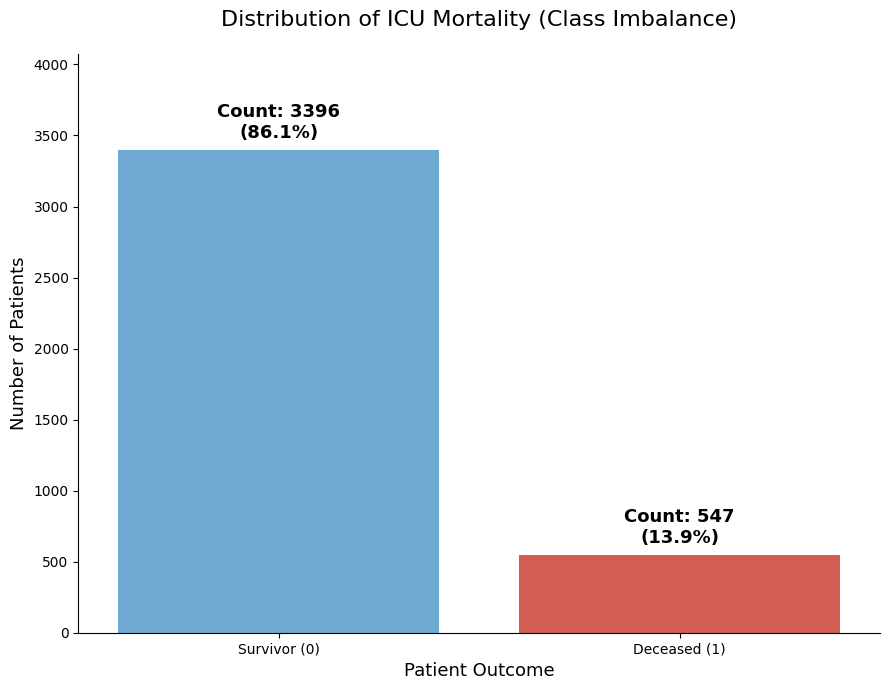

In [15]:
target_counts = df_final['In-hospital_death'].value_counts().sort_index()
target_pcts = df_final['In-hospital_death'].value_counts(normalize=True).sort_index() * 100

labels = ['Survivor (0)', 'Deceased (1)']

plt.figure(figsize=(9, 7))
ax = sns.barplot(x=labels, y=target_counts.values, palette=['#5DADE2', '#E74C3C'])

for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(f'Count: {int(height)}\n({target_pcts.iloc[i]:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='black', xytext=(0, 20),
                textcoords='offset points')

plt.title('Distribution of ICU Mortality (Class Imbalance)', fontsize=16, pad=20)
plt.ylabel('Number of Patients', fontsize=13)
plt.xlabel('Patient Outcome', fontsize=13)

plt.ylim(0, target_counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig("Distribution of ICU Mortality (Class Imbalance).png", dpi=300, bbox_inches="tight")
plt.show()

<h1>Shapiro-Wilk test</h1>

In [16]:
shapiro_results = []

for col in df_final.columns:
    stat, p_value = shapiro(df_final[col])

    shapiro_results.append({
        'Feature': col,
        'Statistic': stat,
        'p-value': p_value,
        'Normal': 'Yes' if p_value > 0.05 else 'No'
    })

df_shapiro_all = pd.DataFrame(shapiro_results)
print("\nShapiro-Wilk Normality Test\n")
print(df_shapiro_all)


Shapiro-Wilk Normality Test

              Feature  Statistic       p-value Normal
0                 Age   0.955360  3.890329e-33     No
1                 BUN   0.755848  1.852262e-60     No
2          Creatinine   0.557466  5.058274e-72     No
3                FiO2   0.948323  3.708320e-35     No
4                 GCS   0.894511  6.596303e-46     No
5              Gender   0.630746  2.157153e-68     No
6             Glucose   0.872842  5.733037e-49     No
7                HCO3   0.975720  2.111754e-25     No
8                 HCT   0.968149  1.027071e-28     No
9                  HR   0.996065  1.008812e-08     No
10             Height   0.620383  6.097623e-69     No
11            ICUType   0.862085  2.489316e-50     No
12                  K   0.963695  2.171136e-30     No
13            Lactate   0.684247  2.481905e-65     No
14                 Mg   0.898115  2.385163e-45     No
15          NIDiasABP   0.986301  4.048826e-19     No
16              NIMAP   0.975902  2.593452e-25     N

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


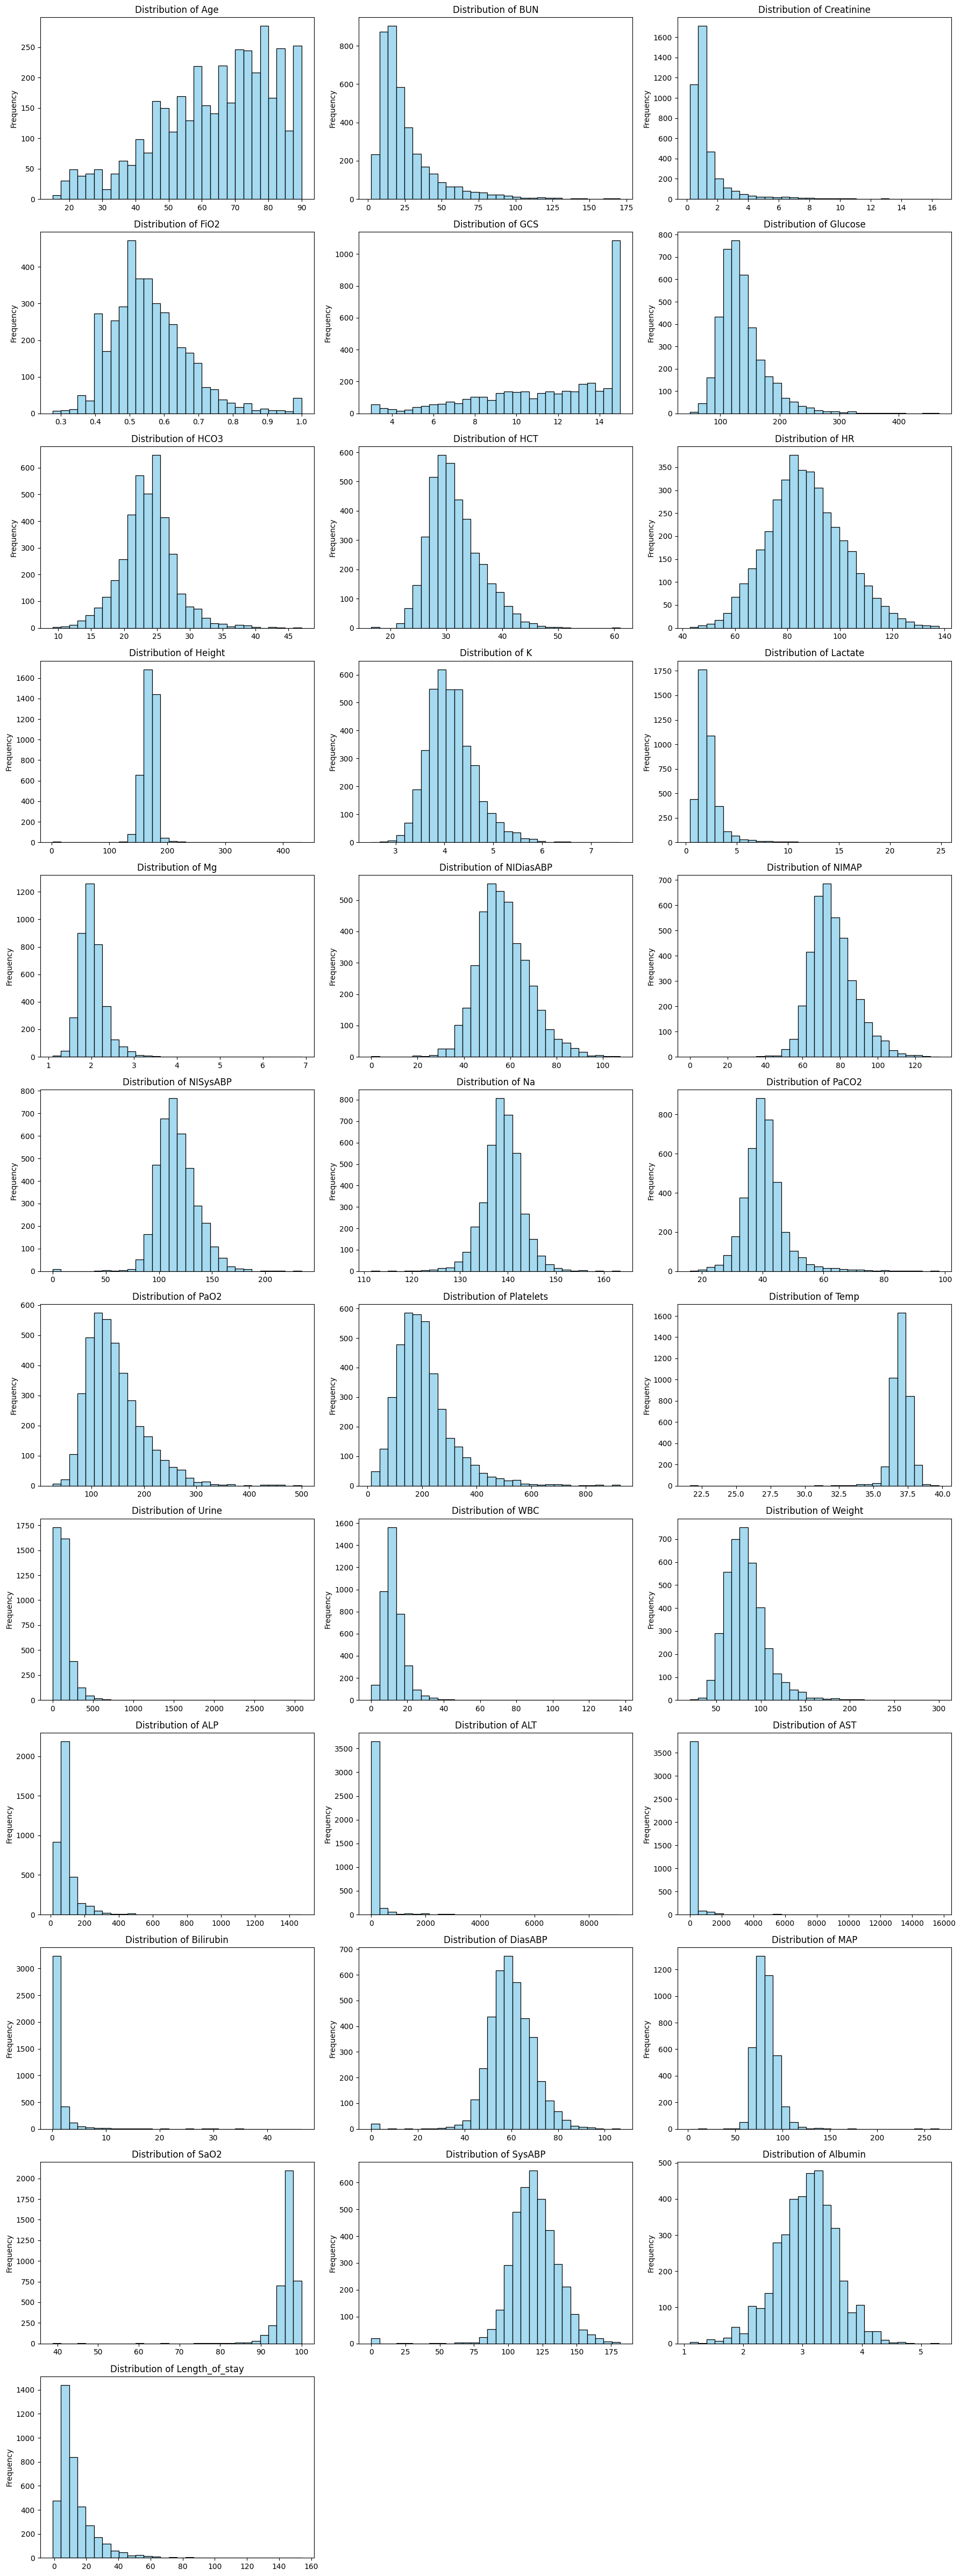

In [17]:
exclude_cols = [
    'gender', 'Gender',
    'ICUType',
    'MechVent',
    'pH',
    'survival', 'Survival',
    'hospital_deaths', 'In-hospital_death',
    'RecordID', 'SAPS-I', 'SOFA'
]

numerical_features = [
    col for col in df_final.select_dtypes(include=['number']).columns
    if col not in exclude_cols
]

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(
        df_final[col],
        bins=30,
        ax=axes[i],
        kde=False,
        color='skyblue',
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Histograms.png", dpi=300, bbox_inches="tight")
plt.show()

<h1>MCSPCA</h1>

In [18]:
df_mcspca = df_final.copy()

outcome_cols = ['SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']
target_col = 'In-hospital_death'
features = [c for c in df_mcspca.columns if c not in outcome_cols]

X = df_mcspca[features]
y = df_mcspca[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def perform_mcspca(X, y):

    n_death = (y == 1).sum()
    n_survive = (y == 0).sum()
    weight_ratio = n_death / n_survive

    weights = np.where(y == 1, 1.0, weight_ratio)

    W = np.diag(weights)
    X_centered = X - np.average(X, axis=0, weights=weights)
    weighted_cov = (X_centered.T @ W @ X_centered) / np.sum(weights)

    eigenvalues, eigenvectors = np.linalg.eigh(weighted_cov)

    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors

eigenvalues, eigenvectors = perform_mcspca(X_scaled, y)

total_variance = np.sum(eigenvalues)
var_explained = np.cumsum(eigenvalues) / total_variance
k = np.argmax(var_explained >= 0.95) + 1

loadings = np.sum(np.abs(eigenvectors[:, :k]), axis=1)
feature_importance = pd.Series(loadings, index=features).sort_values(ascending=False)

top_features = feature_importance.head(15).index.tolist()

print(f"Number of components to explain 95% variance: {k}")
print("Top Features identified by MCSPCA:")
print(feature_importance.head(15))

Number of components to explain 95% variance: 28
Top Features identified by MCSPCA:
Urine        4.329296
Na           4.239680
Mg           4.178809
FiO2         4.159188
Lactate      4.156553
SaO2         4.150016
Weight       4.140764
Temp         4.101275
WBC          4.092568
K            4.003404
ICUType      3.984842
Platelets    3.914222
Glucose      3.876452
GCS          3.831182
PaO2         3.780531
dtype: float64


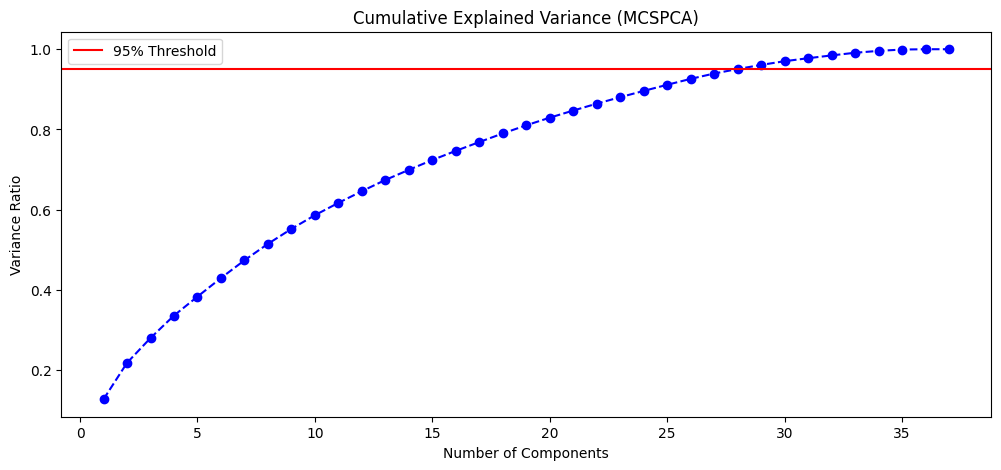

In [19]:
# Cumulative Variance
plt.figure(figsize=(12, 5))

plt.plot(range(1, len(var_explained) + 1), var_explained, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')
plt.title('Cumulative Explained Variance (MCSPCA)')
plt.xlabel('Number of Components')
plt.ylabel('Variance Ratio')
plt.legend()
plt.savefig("Cumulative Variance.png", dpi=300, bbox_inches="tight")
plt.show()

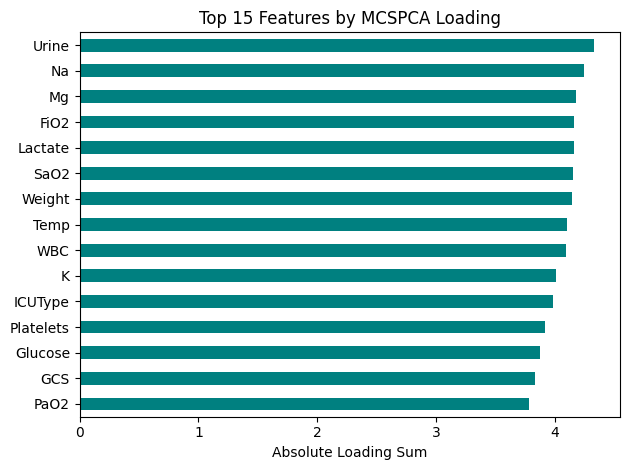

In [20]:
# Top Feature Loadings
feature_importance.head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Features by MCSPCA Loading')
plt.xlabel('Absolute Loading Sum')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("Top Feature Loadings.png", dpi=300, bbox_inches="tight")
plt.show()


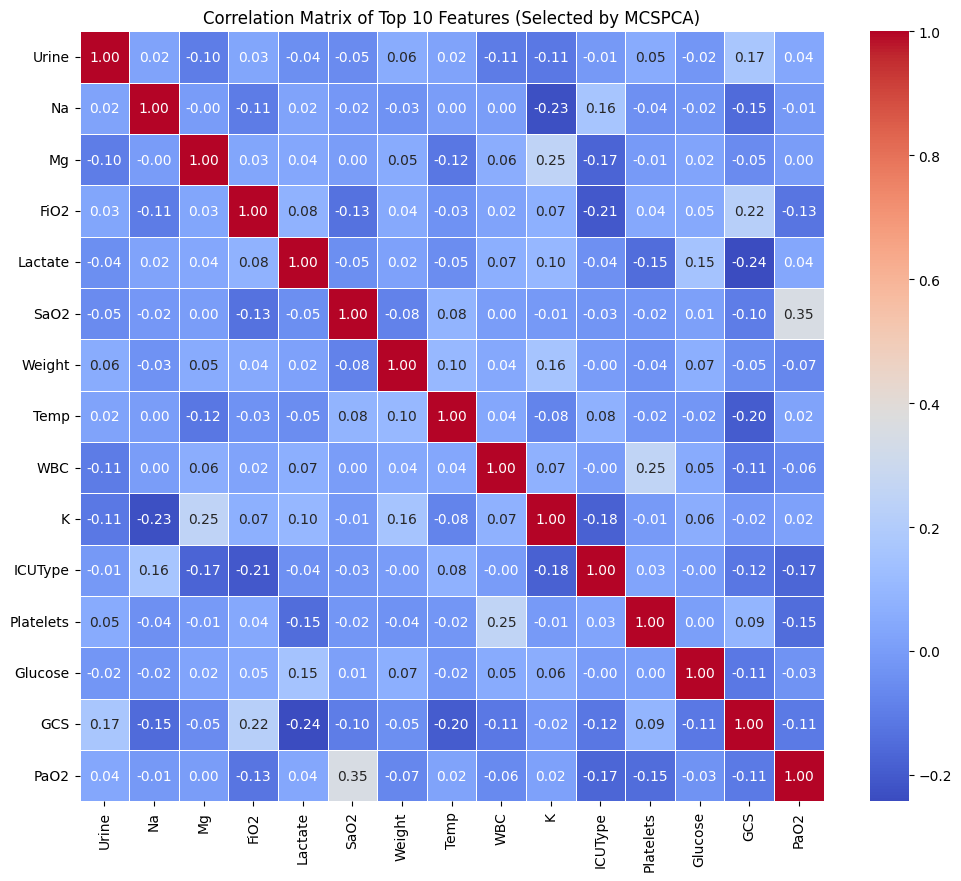

In [21]:
# correlation matrix of the best features from MCSPCA
plt.figure(figsize=(12, 10))
corr_matrix = df_mcspca[top_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Top 10 Features (Selected by MCSPCA)')
plt.savefig("correlation matrix.png", dpi=300, bbox_inches="tight")
plt.show()

<h1>Models</h1>


In [31]:
selected_features = [
    "Urine", "Na", "Mg", "FiO2", "Lactate", "SaO2", "Weight",
    "Temp", "WBC", "K", "ICUType", "Platelets", "Glucose", "GCS", "PaO2"
]

X = df_final[selected_features]
y = df_final['In-hospital_death']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

<h1>RandomForest model</h1>

In [32]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])


<h1>Decision Trees Model</h1>

In [33]:
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

<h1>KNN Model</h1>

In [34]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(
        n_neighbors=5,
        metric='manhattan'  # Manhattan distance
    ))
])

<h1>Model Evaluation Comparison</h1>

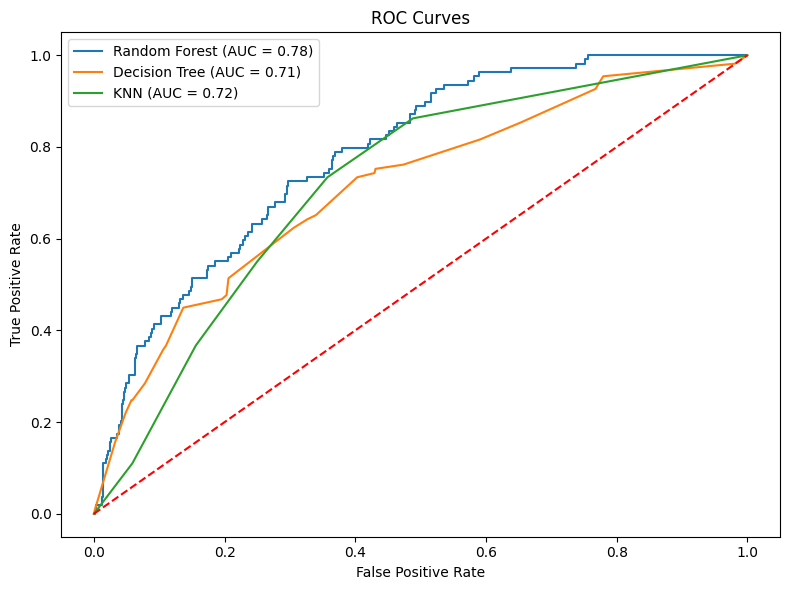

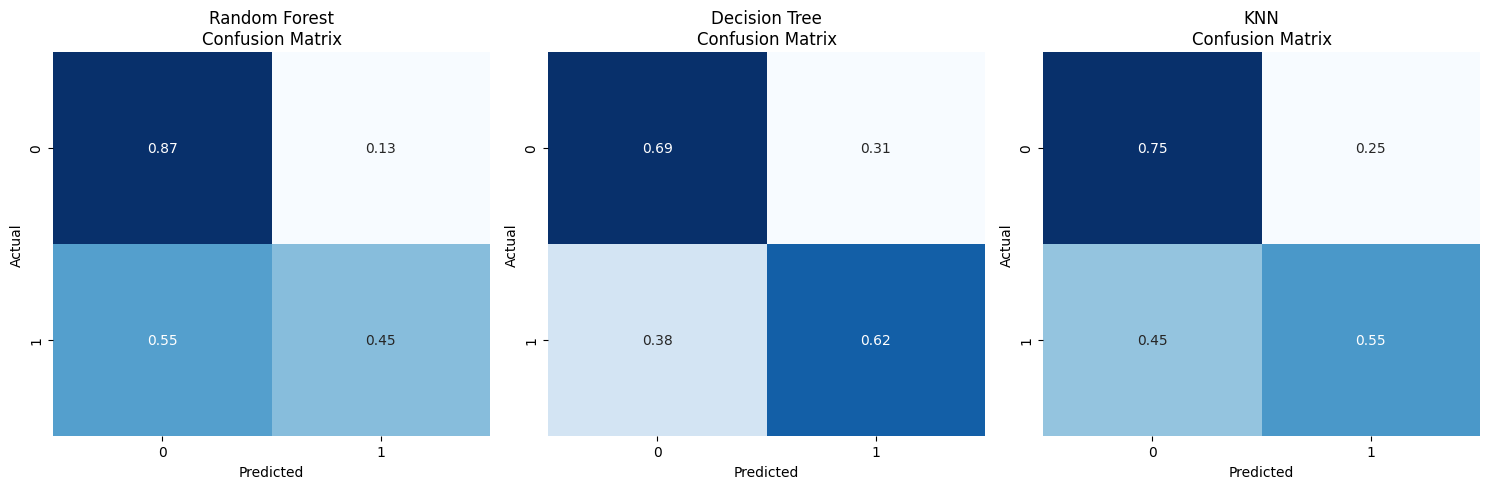


Model Evaluation Comparison
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.886051   0.861890 0.920833  0.889147
Decision Tree  0.747243   0.724287 0.800420  0.757225
          KNN  0.855485   0.782977 0.983798  0.871938


In [36]:
models = {
    'Random Forest': rf_pipeline,
    'Decision Tree': dt_pipeline,
    'KNN': knn_pipeline
}


scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
comparison_metrics = []

for name, model in models.items():

    cv_results = cross_validate(
        model, X_train_res, y_train_res, cv=5, scoring=scoring
    )

    model.fit(X_train_res, y_train_res)

    comparison_metrics.append({
        'Model':     name,
        'Accuracy':  cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall':    cv_results['test_recall'].mean(),
        'F1-Score':  cv_results['test_f1'].mean(),
    })


# ROC Curves
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig("ROC_Curves.png", dpi=300, bbox_inches="tight")
plt.show()


# Confusion Matrices
plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False)
    plt.title(f'{name}\nConfusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.savefig("Confusion_Matrices.png", dpi=300, bbox_inches="tight")
plt.show()

comparison_df = pd.DataFrame(comparison_metrics)
print("\nModel Evaluation Comparison")
print(comparison_df.to_string(index=False))